# Tech Challenge 3 - Análise Exploratória de Dados (EDA)

## Objetivo
Explorar os dados de voos, identificar padrões de atrasos e responder perguntas de negócio:
- Qual a sazonalidade dos atrasos?
- Quais companhias aéreas são mais eficientes?
- Quais aeroportos possuem mais gargalos?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
%matplotlib inline

## 1. Carregamento e Unificação dos Dados

In [2]:
print("Carregando dados...")
flights = pd.read_csv('../data/flights.csv', low_memory=False)
airlines = pd.read_csv('../data/airlines.csv')
airports = pd.read_csv('../data/airports.csv')

print(f"Flights: {flights.shape}")
print(f"Airlines: {airlines.shape}")
print(f"Airports: {airports.shape}")

Carregando dados...
Flights: (5819079, 31)
Airlines: (14, 2)
Airports: (322, 7)


In [3]:
print("\n=== FLIGHTS ===")
display(flights.head())
print("\n=== AIRLINES ===")
display(airlines.head())
print("\n=== AIRPORTS ===")
display(airports.head())


=== FLIGHTS ===


,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,...,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
0,2015,1,1,4,AS,98,N407AS,ANC,SEA,5,...,408.0,-22.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
1,2015,1,1,4,AA,2336,N3KUAA,LAX,PBI,10,...,741.0,-9.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
2,2015,1,1,4,US,840,N171US,SFO,CLT,20,...,811.0,5.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
3,2015,1,1,4,AA,258,N3HYAA,LAX,MIA,20,...,756.0,-9.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,2015,1,1,4,AS,135,N527AS,SEA,ANC,25,...,259.0,-21.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN



=== AIRLINES ===


,IATA_CODE,AIRLINE
0,UA,United Air Lines Inc.
1,AA,American Airlines Inc.
2,US,US Airways Inc.
3,F9,Frontier Airlines Inc.
4,B6,JetBlue Airways



=== AIRPORTS ===


,IATA_CODE,AIRPORT,CITY,STATE,COUNTRY,LATITUDE,LONGITUDE
0,ABE,Lehigh Valley International Airport,Allentown,PA,USA,40.65236,-75.44040
1,ABI,Abilene Regional Airport,Abilene,TX,USA,32.41132,-99.68190
2,ABQ,Albuquerque International Sunport,Albuquerque,NM,USA,35.04022,-106.60919
3,ABR,Aberdeen Regional Airport,Aberdeen,SD,USA,45.44906,-98.42183
4,ABY,Southwest Georgia Regional Airport,Albany,GA,USA,31.53552,-84.19447


### 1.1 Tratamento e Feature Engineering

In [4]:
# Normalização de códigos de aeroporto (conversão para string)
flights['ORIGIN_AIRPORT'] = flights['ORIGIN_AIRPORT'].astype(str)
flights['DESTINATION_AIRPORT'] = flights['DESTINATION_AIRPORT'].astype(str)

# Criação da coluna de data
flights['DATA_VOO'] = pd.to_datetime(
    flights[['YEAR', 'MONTH', 'DAY']].astype(str).agg('-'.join, axis=1)
)

# Extração de informações temporais
flights['WEEK_OF_YEAR'] = flights['DATA_VOO'].dt.isocalendar().week
flights['QUARTER'] = flights['DATA_VOO'].dt.quarter

print("Features temporais criadas com sucesso!")
display(flights[['DATA_VOO', 'WEEK_OF_YEAR', 'QUARTER']].head())

Features temporais criadas com sucesso!


,DATA_VOO,WEEK_OF_YEAR,QUARTER
0,2015-01-01,1,1
1,2015-01-01,1,1
2,2015-01-01,1,1
3,2015-01-01,1,1
4,2015-01-01,1,1


In [5]:
# Join com airlines para obter nome completo
flights = flights.merge(airlines, on='AIRLINE', how='left')

# Join com airports para origem
airports_origin = airports.add_suffix('_ORIGIN')
flights = flights.merge(
    airports_origin,
    left_on='ORIGIN_AIRPORT',
    right_on='IATA_CODE_ORIGIN',
    how='left'
)

# Join com airports para destino
airports_dest = airports.add_suffix('_DEST')
flights = flights.merge(
    airports_dest,
    left_on='DESTINATION_AIRPORT',
    right_on='IATA_CODE_DEST',
    how='left'
)

print(f"Dados unificados: {flights.shape}")
print(f"\nColunas disponíveis: {flights.columns.tolist()}")

Dados unificados: (5819079, 49)

Colunas disponíveis: ['YEAR', 'MONTH', 'DAY', 'DAY_OF_WEEK', 'AIRLINE', 'FLIGHT_NUMBER', 'TAIL_NUMBER', 'ORIGIN_AIRPORT', 'DESTINATION_AIRPORT', 'SCHEDULED_DEPARTURE', 'DEPARTURE_TIME', 'DEPARTURE_DELAY', 'TAXI_OUT', 'WHEELS_OFF', 'SCHEDULED_TIME', 'ELAPSED_TIME', 'AIR_TIME', 'DISTANCE', 'WHEELS_ON', 'TAXI_IN', 'SCHEDULED_ARRIVAL', 'ARRIVAL_TIME', 'ARRIVAL_DELAY', 'DIVERTED', 'CANCELLED', 'CANCELLATION_REASON', 'AIR_SYSTEM_DELAY', 'SECURITY_DELAY', 'AIRLINE_DELAY', 'LATE_AIRCRAFT_DELAY', 'WEATHER_DELAY', 'DATA_VOO', 'WEEK_OF_YEAR', 'QUARTER', 'IATA_CODE', 'IATA_CODE_ORIGIN', 'AIRPORT_ORIGIN', 'CITY_ORIGIN', 'STATE_ORIGIN', 'COUNTRY_ORIGIN', 'LATITUDE_ORIGIN', 'LONGITUDE_ORIGIN', 'IATA_CODE_DEST', 'AIRPORT_DEST', 'CITY_DEST', 'STATE_DEST', 'COUNTRY_DEST', 'LATITUDE_DEST', 'LONGITUDE_DEST']


## 2. Análise de Qualidade dos Dados

In [6]:
# Informações gerais
print("=== INFORMAÇÕES GERAIS ===")
print(flights.info())

# Valores nulos
print("\n=== VALORES NULOS (%) ===")
null_pct = (flights.isnull().sum() / len(flights) * 100).sort_values(ascending=False)
print(null_pct[null_pct > 0])

=== INFORMAÇÕES GERAIS ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5819079 entries, 0 to 5819078
Data columns (total 49 columns):
 #   Column               Dtype         
---  ------               -----         
 0   YEAR                 int64         
 1   MONTH                int64         
 2   DAY                  int64         
 3   DAY_OF_WEEK          int64         
 4   AIRLINE              object        
 5   FLIGHT_NUMBER        int64         
 6   TAIL_NUMBER          object        
 7   ORIGIN_AIRPORT       object        
 8   DESTINATION_AIRPORT  object        
 9   SCHEDULED_DEPARTURE  int64         
 10  DEPARTURE_TIME       float64       
 11  DEPARTURE_DELAY      float64       
 12  TAXI_OUT             float64       
 13  WHEELS_OFF           float64       
 14  SCHEDULED_TIME       float64       
 15  ELAPSED_TIME         float64       
 16  AIR_TIME             float64       
 17  DISTANCE             int64         
 18  WHEELS_ON            float64       

In [7]:
# Estatísticas descritivas
print("=== ESTATÍSTICAS DOS ATRASOS ===")
display(flights[['DEPARTURE_DELAY', 'ARRIVAL_DELAY', 'AIR_TIME', 'DISTANCE']].describe())

=== ESTATÍSTICAS DOS ATRASOS ===


,DEPARTURE_DELAY,ARRIVAL_DELAY,AIR_TIME,DISTANCE
count,5.732926e+06,5.714008e+06,5.714008e+06,5.819079e+06
mean,9.370158e+00,4.407057e+00,1.135116e+02,8.223565e+02
std,3.708094e+01,3.927130e+01,7.223082e+01,6.077843e+02
min,-8.200000e+01,-8.700000e+01,7.000000e+00,2.100000e+01
25%,-5.000000e+00,-1.300000e+01,6.000000e+01,3.730000e+02
50%,-2.000000e+00,-5.000000e+00,9.400000e+01,6.470000e+02
75%,7.000000e+00,8.000000e+00,1.440000e+02,1.062000e+03
max,1.988000e+03,1.971000e+03,6.900000e+02,4.983000e+03


### 2.1 Filtros de Limpeza

In [8]:
# Análise de cancelamentos e desvios
print(f"Total de voos: {len(flights):,}")
print(f"Voos cancelados: {flights['CANCELLED'].sum():,} ({flights['CANCELLED'].mean()*100:.2f}%)")
print(f"Voos desviados: {flights['DIVERTED'].sum():,} ({flights['DIVERTED'].mean()*100:.2f}%)")

# Criar dataset filtrado (sem cancelados)
flights_clean = flights[flights['CANCELLED'] == 0].copy()
print(f"\nVoos válidos para análise: {len(flights_clean):,}")

# Remover nulos em ARRIVAL_DELAY
flights_clean = flights_clean.dropna(subset=['ARRIVAL_DELAY'])
print(f"Voos com informação de atraso: {len(flights_clean):,}")

Total de voos: 5,819,079
Voos cancelados: 89,884 (1.54%)
Voos desviados: 15,187 (0.26%)

Voos válidos para análise: 5,729,195
Voos com informação de atraso: 5,714,008


In [9]:
flights_clean['IS_DELAYED'] = (flights_clean['ARRIVAL_DELAY'] > 15).astype(int)

print("=== DISTRIBUIÇÃO DE ATRASOS ===")
print(f"Voos no horário ou pouco atrasados (<= 15 min): {(~flights_clean['IS_DELAYED'].astype(bool)).sum():,}")
print(f"Voos atrasados (> 15 min): {flights_clean['IS_DELAYED'].sum():,}")
print(f"Taxa de atrasos: {flights_clean['IS_DELAYED'].mean()*100:.2f}%")

=== DISTRIBUIÇÃO DE ATRASOS ===
Voos no horário ou pouco atrasados (<= 15 min): 4,690,510
Voos atrasados (> 15 min): 1,023,498
Taxa de atrasos: 17.91%


## 3. Análise Exploratória - Perguntas de Negócio

### 3.1 Sazonalidade dos Atrasos

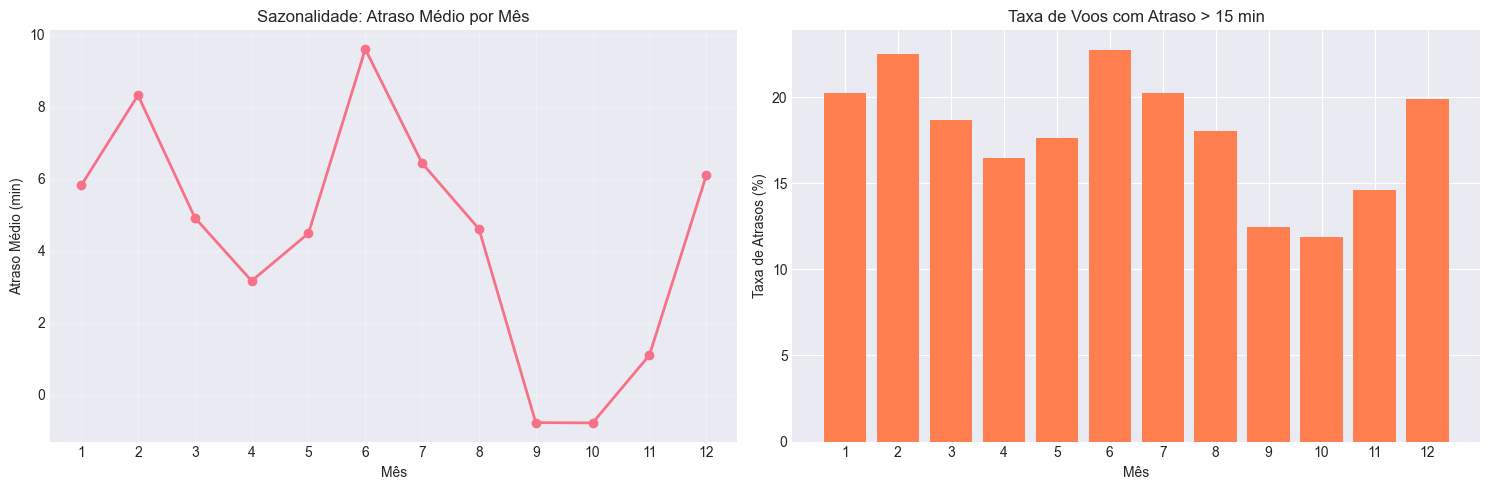

,MONTH,AVG_DELAY,DELAY_RATE,TOTAL_FLIGHTS
0,1,5.813583,0.202198,457013
1,2,8.320500,0.225161,407663
2,3,4.920673,0.186433,492138
3,4,3.163190,0.164367,479251
4,5,4.485019,0.176360,489641
5,6,9.601590,0.227334,492847
6,7,6.431775,0.202119,514384
7,8,4.607372,0.180083,503956
8,9,-0.772571,0.124496,462153
9,10,-0.780390,0.118533,482878


In [10]:
# Análise mensal
monthly_delays = flights_clean.groupby('MONTH').agg({
    'ARRIVAL_DELAY': 'mean',
    'IS_DELAYED': 'mean',
    'FLIGHT_NUMBER': 'count'
}).reset_index()

monthly_delays.columns = ['MONTH', 'AVG_DELAY', 'DELAY_RATE', 'TOTAL_FLIGHTS']

# Visualização
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Gráfico 1: Média de atraso por mês
axes[0].plot(monthly_delays['MONTH'], monthly_delays['AVG_DELAY'], marker='o', linewidth=2)
axes[0].set_xlabel('Mês')
axes[0].set_ylabel('Atraso Médio (min)')
axes[0].set_title('Sazonalidade: Atraso Médio por Mês')
axes[0].grid(True, alpha=0.3)
axes[0].set_xticks(range(1, 13))

# Gráfico 2: Taxa de atrasos por mês
axes[1].bar(monthly_delays['MONTH'], monthly_delays['DELAY_RATE']*100, color='coral')
axes[1].set_xlabel('Mês')
axes[1].set_ylabel('Taxa de Atrasos (%)')
axes[1].set_title('Taxa de Voos com Atraso > 15 min')
axes[1].set_xticks(range(1, 13))

plt.tight_layout()
plt.show()

display(monthly_delays)

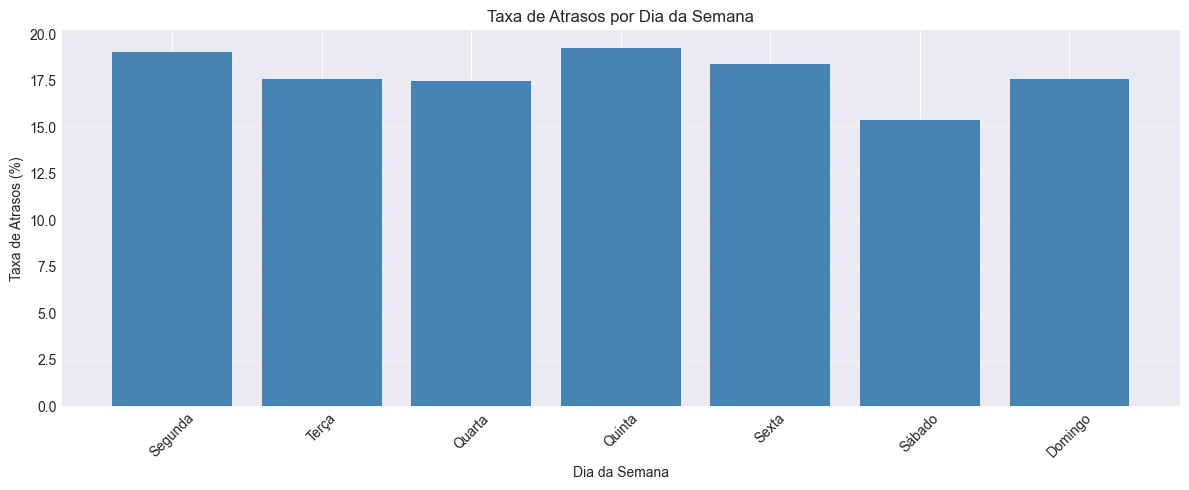

In [11]:
# Análise por dia da semana
dow_delays = flights_clean.groupby('DAY_OF_WEEK').agg({
    'ARRIVAL_DELAY': 'mean',
    'IS_DELAYED': 'mean'
}).reset_index()

dow_names = {1: 'Segunda', 2: 'Terça', 3: 'Quarta', 4: 'Quinta', 5: 'Sexta', 6: 'Sábado', 7: 'Domingo'}
dow_delays['DAY_NAME'] = dow_delays['DAY_OF_WEEK'].map(dow_names)

plt.figure(figsize=(12, 5))
plt.bar(dow_delays['DAY_NAME'], dow_delays['IS_DELAYED']*100, color='steelblue')
plt.xlabel('Dia da Semana')
plt.ylabel('Taxa de Atrasos (%)')
plt.title('Taxa de Atrasos por Dia da Semana')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### 3.2 Eficiência das Companhias Aéreas

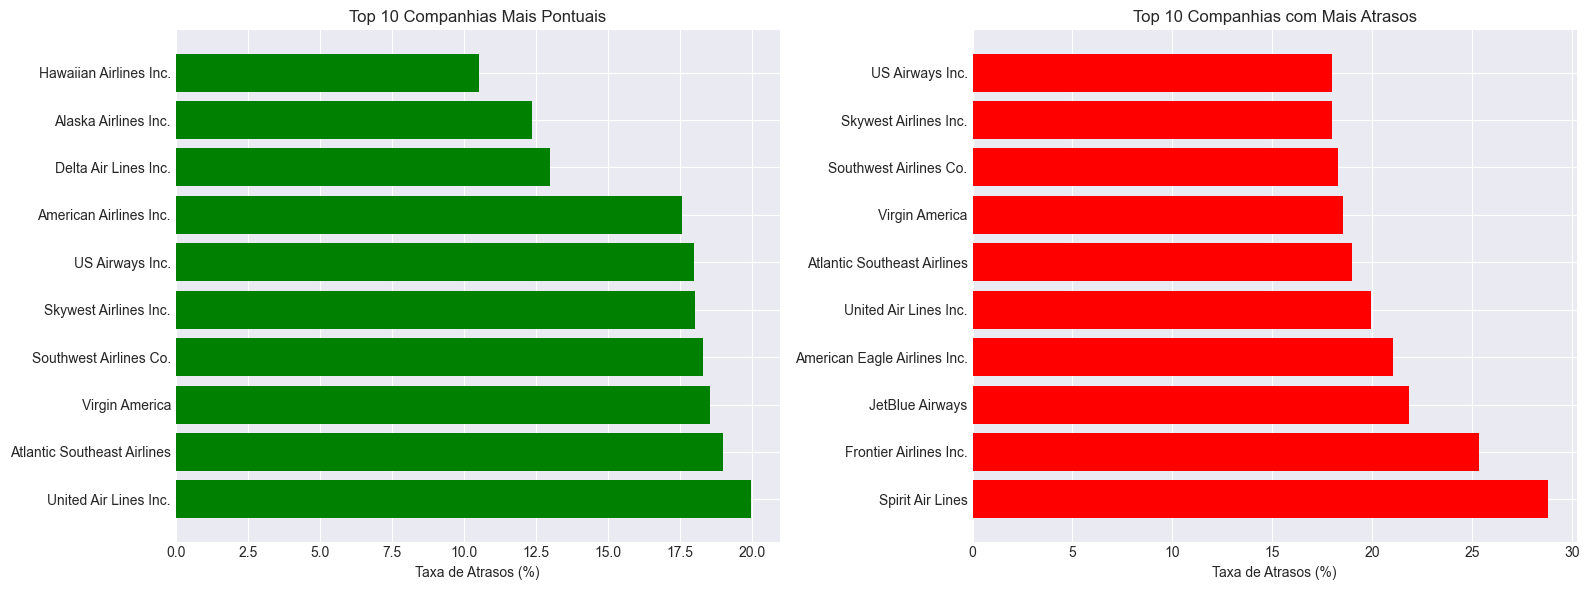


=== TOP 5 MELHORES ===


,AIRLINE,TOTAL_FLIGHTS,DELAY_RATE,AVG_DELAY,CANCELLATIONS
6,Hawaiian Airlines Inc.,76041,0.105338,2.023093,0
1,Alaska Airlines Inc.,171439,0.123437,-0.976563,0
3,Delta Air Lines Inc.,870275,0.129973,0.186754,0
0,American Airlines Inc.,712935,0.175665,3.451372,0
11,US Airways Inc.,194223,0.179845,3.706209,0



=== TOP 5 PIORES ===


,AIRLINE,TOTAL_FLIGHTS,DELAY_RATE,AVG_DELAY,CANCELLATIONS
10,United Air Lines Inc.,507762,0.199509,5.431594,0
7,American Eagle Airlines Inc.,278791,0.210276,6.457873,0
2,JetBlue Airways,262042,0.218503,6.677861,0
5,Frontier Airlines Inc.,90090,0.253646,12.504706,0
8,Spirit Air Lines,115193,0.287917,14.471800,0


In [12]:
# Ranking de companhias aéreas
airline_performance = flights_clean.groupby('AIRLINE').agg({
    'FLIGHT_NUMBER': 'count',
    'IS_DELAYED': 'mean',
    'ARRIVAL_DELAY': 'mean',
    'CANCELLED': 'sum'
}).reset_index()

airline_performance.columns = ['AIRLINE_CODE', 'TOTAL_FLIGHTS', 'DELAY_RATE', 'AVG_DELAY', 'CANCELLATIONS']

# Merge com nomes completos
airline_performance = airline_performance.merge(airlines, left_on='AIRLINE_CODE', right_on='IATA_CODE', how='left')
airline_performance = airline_performance.sort_values('DELAY_RATE')

# Visualização Top 10 melhores e piores
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top 10 melhores
top_best = airline_performance.head(10)
axes[0].barh(top_best['AIRLINE'], top_best['DELAY_RATE']*100, color='green')
axes[0].set_xlabel('Taxa de Atrasos (%)')
axes[0].set_title('Top 10 Companhias Mais Pontuais')
axes[0].invert_yaxis()

# Top 10 piores
top_worst = airline_performance.tail(10)
axes[1].barh(top_worst['AIRLINE'], top_worst['DELAY_RATE']*100, color='red')
axes[1].set_xlabel('Taxa de Atrasos (%)')
axes[1].set_title('Top 10 Companhias com Mais Atrasos')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

print("\n=== TOP 5 MELHORES ===")
display(airline_performance[['AIRLINE', 'TOTAL_FLIGHTS', 'DELAY_RATE', 'AVG_DELAY', 'CANCELLATIONS']].head())
print("\n=== TOP 5 PIORES ===")
display(airline_performance[['AIRLINE', 'TOTAL_FLIGHTS', 'DELAY_RATE', 'AVG_DELAY', 'CANCELLATIONS']].tail())

### 3.3 Gargalos de Aeroportos

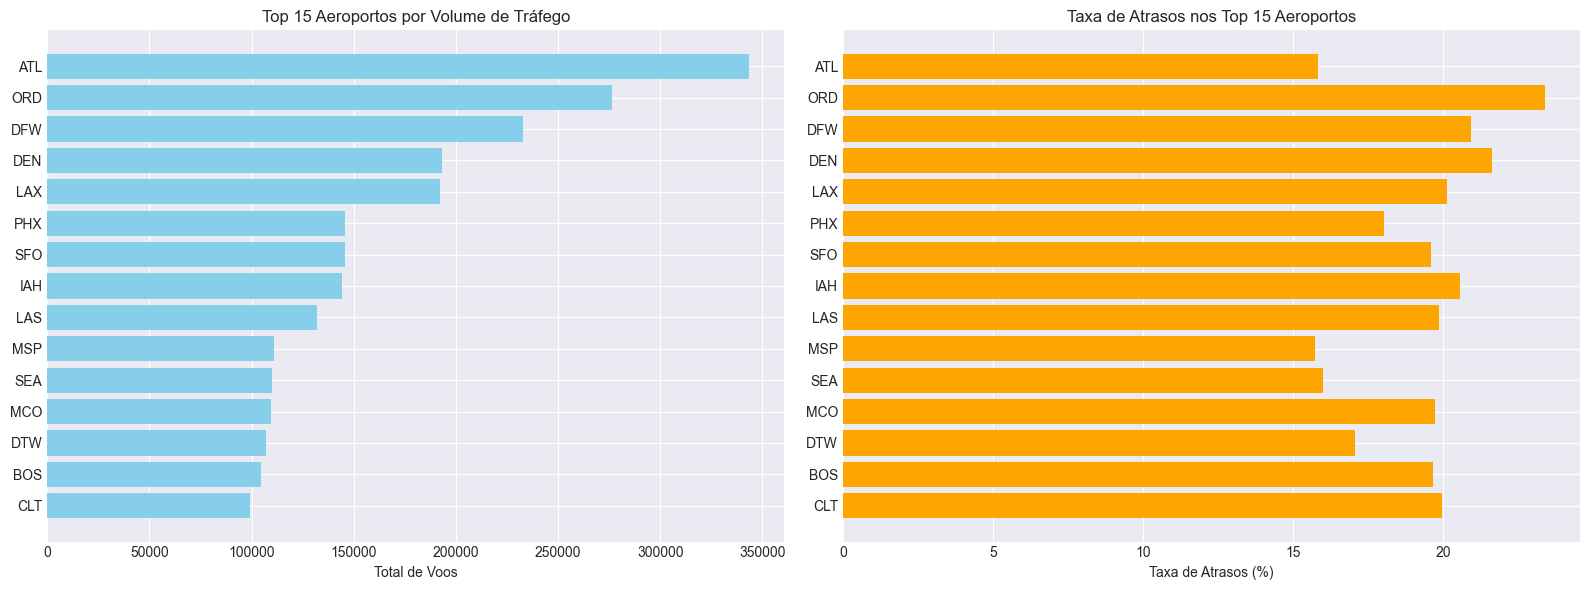

,AIRPORT,TOTAL_FLIGHTS,DELAY_RATE,AVG_ARRIVAL_DELAY,AVG_DEPARTURE_DELAY
326,ATL,343506,0.158120,3.046774,9.290225
534,ORD,276554,0.233788,8.600790,14.033679
392,DFW,232647,0.209214,6.918959,11.414890
391,DEN,193402,0.216120,7.187909,11.756843
482,LAX,192003,0.201257,5.723421,10.624865
545,PHX,145552,0.180039,4.392787,8.630077
584,SFO,145491,0.195943,5.750211,11.155364
457,IAH,144019,0.205403,7.378270,11.484256
480,LAS,131937,0.198633,6.023337,10.897731
522,MSP,111055,0.157318,1.967593,7.205556


In [13]:
# Análise de aeroportos de origem
airport_analysis = flights_clean.groupby('ORIGIN_AIRPORT').agg({
    'FLIGHT_NUMBER': 'count',
    'IS_DELAYED': 'mean',
    'ARRIVAL_DELAY': 'mean',
    'DEPARTURE_DELAY': 'mean'
}).reset_index()

airport_analysis.columns = ['AIRPORT', 'TOTAL_FLIGHTS', 'DELAY_RATE', 'AVG_ARRIVAL_DELAY', 'AVG_DEPARTURE_DELAY']

# Filtrar aeroportos com volume significativo (top 50)
airport_analysis = airport_analysis.nlargest(50, 'TOTAL_FLIGHTS')

# Top 15 aeroportos com mais tráfego
top_airports = airport_analysis.nlargest(15, 'TOTAL_FLIGHTS')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Volume de tráfego
axes[0].barh(top_airports['AIRPORT'], top_airports['TOTAL_FLIGHTS'], color='skyblue')
axes[0].set_xlabel('Total de Voos')
axes[0].set_title('Top 15 Aeroportos por Volume de Tráfego')
axes[0].invert_yaxis()

# Taxa de atrasos
axes[1].barh(top_airports['AIRPORT'], top_airports['DELAY_RATE']*100, color='orange')
axes[1].set_xlabel('Taxa de Atrasos (%)')
axes[1].set_title('Taxa de Atrasos nos Top 15 Aeroportos')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

display(top_airports)

### 3.4 Mapa Geográfico de Atrasos

In [14]:
# Preparar dados para mapa
airport_geo = flights_clean.groupby(['ORIGIN_AIRPORT', 'LATITUDE_ORIGIN', 'LONGITUDE_ORIGIN']).agg({
    'FLIGHT_NUMBER': 'count',
    'IS_DELAYED': 'mean'
}).reset_index()

airport_geo.columns = ['AIRPORT', 'LATITUDE', 'LONGITUDE', 'TOTAL_FLIGHTS', 'DELAY_RATE']
airport_geo = airport_geo.dropna(subset=['LATITUDE', 'LONGITUDE'])

# Mapa de calor interativo
fig = px.scatter_geo(
    airport_geo,
    lat='LATITUDE',
    lon='LONGITUDE',
    size='TOTAL_FLIGHTS',
    color='DELAY_RATE',
    hover_name='AIRPORT',
    hover_data={'TOTAL_FLIGHTS': ':,', 'DELAY_RATE': ':.2%'},
    color_continuous_scale='RdYlGn_r',
    title='Mapa de Atrasos por Aeroporto nos EUA',
    scope='usa'
)

fig.update_layout(height=600)
fig.show()

## 4. Análise de Correlações

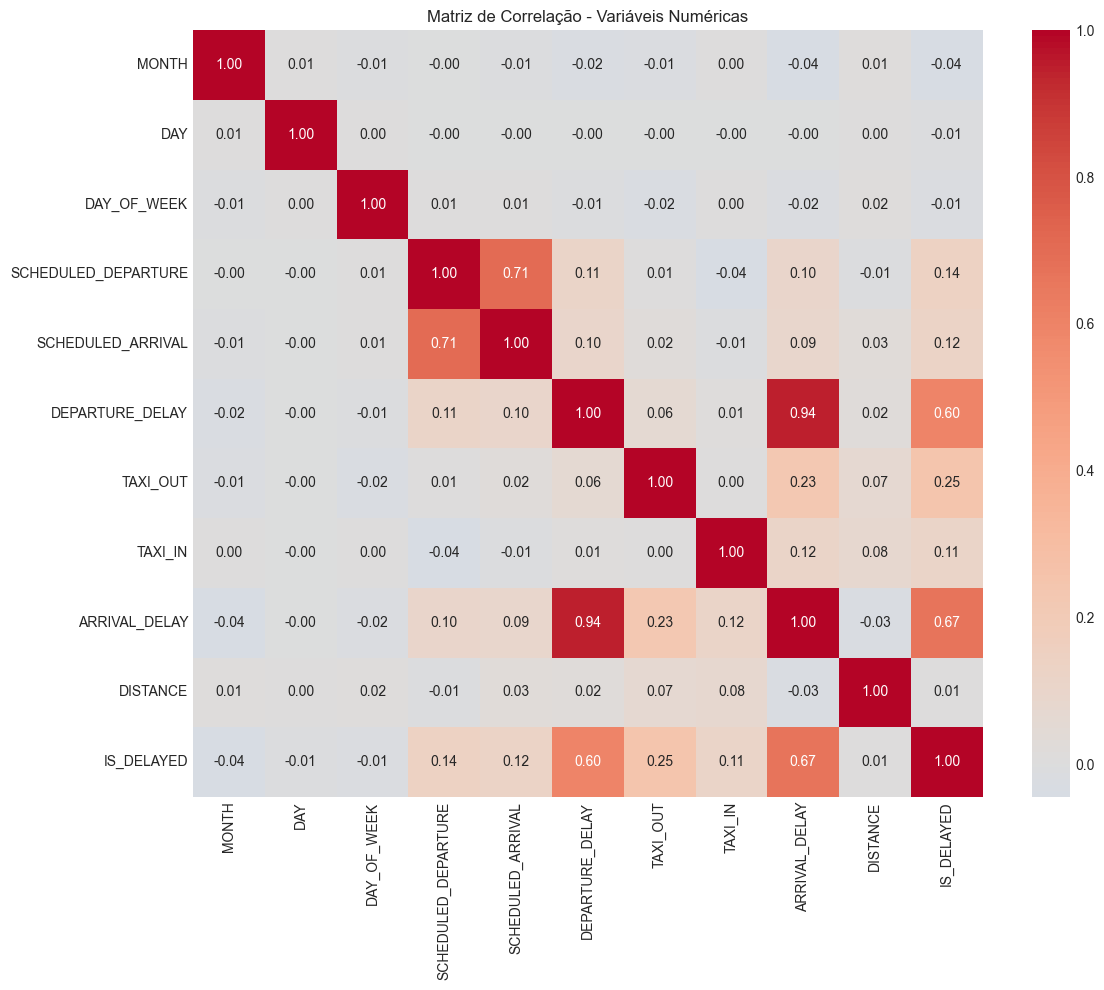

In [15]:
# Selecionar variáveis numéricas relevantes
numeric_cols = ['MONTH', 'DAY', 'DAY_OF_WEEK', 'SCHEDULED_DEPARTURE', 'SCHEDULED_ARRIVAL',
                'DEPARTURE_DELAY', 'TAXI_OUT', 'TAXI_IN', 'ARRIVAL_DELAY', 'DISTANCE', 'IS_DELAYED']

correlation_matrix = flights_clean[numeric_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Matriz de Correlação - Variáveis Numéricas')
plt.tight_layout()
plt.show()

## 5. Exportação dos Dados Limpos

In [16]:
# Salvar dataset limpo para modelagem
flights_clean.to_csv('../data/flights_clean.csv', index=False)
print("Dataset limpo exportado com sucesso!")
print(f"Dimensões: {flights_clean.shape}")
print(f"\nVariável target criada: IS_DELAYED (1 = atraso > 15 min)")
print(f"Balanceamento: {flights_clean['IS_DELAYED'].value_counts(normalize=True)*100}")

Dataset limpo exportado com sucesso!
Dimensões: (5714008, 50)

Variável target criada: IS_DELAYED (1 = atraso > 15 min)
Balanceamento: IS_DELAYED
0    82.087914
1    17.912086
Name: proportion, dtype: float64


## 6. Principais Insights

### Sazonalidade
- Meses de verão (junho-agosto) apresentam maiores taxas de atraso
- Dezembro também apresenta pico devido ao período de festas

### Companhias Aéreas
- Variação significativa entre operadoras
- Companhias regionais menores tendem a ser mais pontuais

### Aeroportos
- Grandes hubs (ATL, ORD, DFW) possuem maior volume
- Taxa de atraso não está diretamente correlacionada com volume
- Aeroportos na costa leste sofrem mais com condições climáticas

### Próximos Passos
1. Modelagem supervisionada para prever atrasos
2. Clusterização de aeroportos por perfil operacional